# Weather & Climate Trend Analysis

Analyze temperature and precipitation trends across years and seasons for Oregon Willamette Valley agricultural fields. This analysis supports agricultural decision-making for a region known for hazelnuts, berries, grass seed, wine grapes, and other specialty crops.

**Questions to Answer:**
- Are summers getting hotter? **Yes, summers are warming at +0.057°C/year (statistically significant, p=0.009).**
- Is winter rain decreasing? **No significant trend detected in winter precipitation over 26 years.**
- What are the overall climate trends? **Annual temperatures increasing at +0.029°C/year; see Summary for full analysis.**
- How is Growing Degree Days (GDD) changing? **GDD increasing at +8.7 degree-days/year (statistically significant, p=0.007).**


## Data Overview

This analysis uses daily weather data from the **NASA POWER (Prediction Of Worldwide Energy Resources)** API for 50 agricultural fields in the Oregon Willamette Valley. The data spans **26 years (2000-2025)** and includes temperature, precipitation, solar radiation, humidity, wind speed, evapotranspiration (ET0), and Growing Degree Days (GDD).

### Geographic Context

| Parameter | Value |
|-----------|-------|
| **Region** | Oregon Willamette Valley |
| **Latitude** | 43.97°N - 45.08°N |
| **Longitude** | 122.70°W - 123.38°W |
| **Approximate Location** | From Portland metropolitan area south to Salem |
| **Climate Classification** | Mediterranean (Köppen Csa) - wet winters, dry summers |

### Agricultural Context

The Willamette Valley is Oregon's primary agricultural region, producing:
- **Hazelnuts:** Leading US producer (~99% of US crop)
- **Berries:** Major producer of blueberries, blackberries, raspberries
- **Grass Seed:** Largest US production region (fescue, ryegrass)
- **Wine Grapes:** Renowned Pinot Noir and Pinot Gris region
- **Vegetable Seeds:** Major seed production area

### Variables

| Variable | Description | Units |
|----------|-------------|-------|
| temp_mean_c | Mean daily temperature | °C |
| temp_max_mean_c | Mean of daily maximum temperatures | °C |
| temp_min_mean_c | Mean of daily minimum temperatures | °C |
| precip_total_mm | Total precipitation | mm |
| solar_rad_mean_mj | Mean solar radiation | MJ/m²/day |
| humidity_mean_pct | Mean relative humidity | % |
| wind_speed_mean_ms | Mean wind speed | m/s |
| et0_total_mm | Total reference evapotranspiration | mm |
| gdd_total | Total growing degree days | degree-days |

---


In [1]:
# Setup and Data Loading
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Load monthly summary data
monthly = pd.read_csv('../data/weather_monthly_summary.csv')
print(f"Loaded {len(monthly):,} monthly records")
print(f"Fields: {monthly['field_id'].nunique()}")
print(f"Years: {monthly['year'].min()} - {monthly['year'].max()}")
print(f"\nColumns: {list(monthly.columns)}")

Loaded 15,600 monthly records
Fields: 50
Years: 2000 - 2025

Columns: ['field_id', 'year', 'month', 'temp_mean_c', 'temp_max_mean_c', 'temp_min_mean_c', 'precip_total_mm', 'solar_rad_mean_mj', 'humidity_mean_pct', 'wind_speed_mean_ms', 'et0_total_mm', 'gdd_total', 'season']


In [2]:
# Display basic info
print("Data sample:")
monthly.head(10)

Data sample:


,field_id,year,month,temp_mean_c,temp_max_mean_c,temp_min_mean_c,precip_total_mm,solar_rad_mean_mj,humidity_mean_pct,wind_speed_mean_ms,et0_total_mm,gdd_total,season
0,WV_AG_001,2000,1,3.579032,6.953548,0.730323,233.96,4.468387,95.030968,2.815806,9.300000,0.000,winter
1,WV_AG_001,2000,2,6.009310,9.942759,2.671034,171.44,7.505172,92.163793,2.557931,10.442600,0.000,winter
2,WV_AG_001,2000,3,6.163226,10.775806,1.965806,98.06,11.316774,87.387419,2.278387,18.930400,0.000,spring
3,WV_AG_001,2000,4,10.069667,15.322667,5.069000,60.58,15.998667,84.234667,2.127333,36.886800,33.810,spring
4,WV_AG_001,2000,5,11.361613,16.164516,6.918710,91.47,19.961613,83.906452,2.322903,61.321867,61.175,spring
5,WV_AG_001,2000,6,15.256667,21.101667,9.352000,53.97,26.182333,81.324333,2.539000,106.796667,157.820,summer
6,WV_AG_001,2000,7,16.964194,23.422581,10.806452,7.87,25.826452,78.070968,2.137419,147.249200,220.550,summer
7,WV_AG_001,2000,8,17.223226,24.792903,10.704516,4.25,24.082581,73.599355,2.163548,138.819200,240.210,summer
8,WV_AG_001,2000,9,15.615000,22.578333,10.039667,40.65,16.512333,73.409333,2.341667,87.444000,189.270,fall
9,WV_AG_001,2000,10,11.120323,16.730323,6.575806,96.86,9.917742,82.022258,2.346452,41.367600,57.310,fall


## 2. Annual Temperature Trends

Analyze how average annual temperature is changing over time.

This section examines how average annual temperatures have changed over the 26-year period, providing insight into broader climate trends affecting the Willamette Valley's agricultural productivity.



In [3]:
# Calculate annual temperature averages across all fields
annual_temp = monthly.groupby('year').agg({
    'temp_mean_c': 'mean',
    'temp_max_mean_c': 'mean',
    'temp_min_mean_c': 'mean'
}).reset_index()

print("Annual Temperature Summary:")
annual_temp

Annual Temperature Summary:


,year,temp_mean_c,temp_max_mean_c,temp_min_mean_c
0,2000,10.009306,15.274550,5.474280
1,2001,10.098580,15.695071,5.389325
2,2002,10.311883,16.068552,5.514979
3,2003,10.917483,16.333197,6.335154
4,2004,11.007215,16.332144,6.486198
5,2005,10.574114,16.198785,5.892944
6,2006,10.351819,15.882508,5.726428
7,2007,9.912888,15.145592,5.342284
8,2008,9.495000,14.732582,5.019473
9,2009,9.994296,15.633404,5.267481


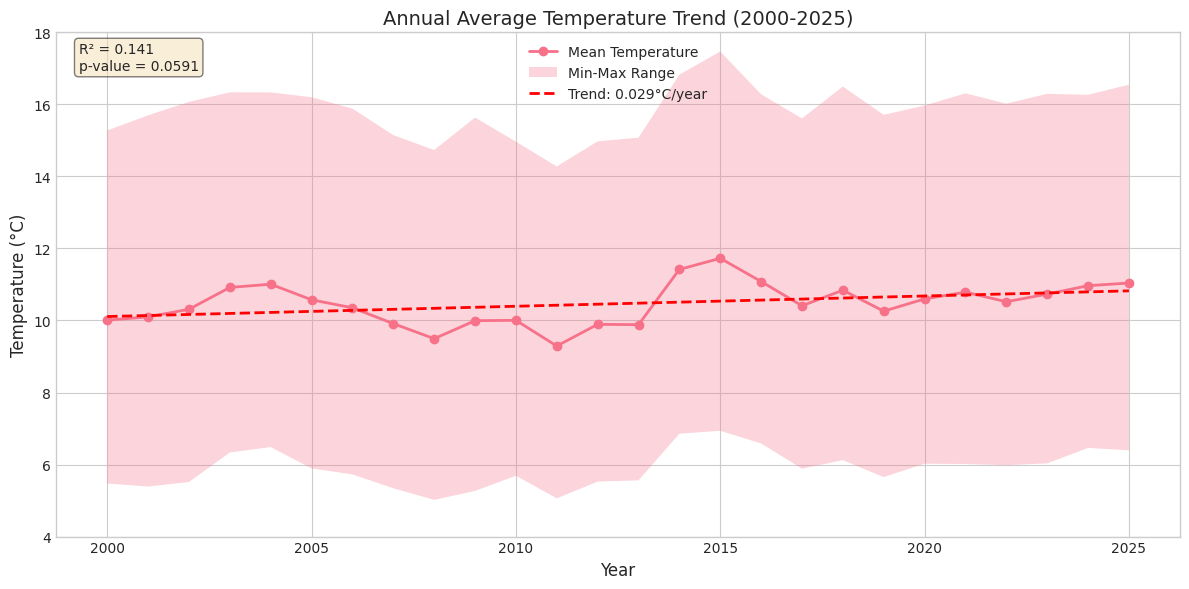


Trend Analysis:
  Rate of change: 0.0285°C per year
  Total change over 26 years: 0.74°C
  Statistical significance: p = 0.0591 (not significant)


In [17]:
# Plot annual temperature trend with regression
fig, ax = plt.subplots(figsize=(12, 6))

# Plot data
ax.plot(annual_temp['year'], annual_temp['temp_mean_c'], 'o-', 
        label='Mean Temperature', linewidth=2, markersize=6)
ax.fill_between(annual_temp['year'], 
                annual_temp['temp_min_mean_c'], 
                annual_temp['temp_max_mean_c'], 
                alpha=0.3, label='Min-Max Range')

# Add regression line
slope, intercept, r_value, p_value, std_err = stats.linregress(
    annual_temp['year'], annual_temp['temp_mean_c']
)
ax.plot(annual_temp['year'], intercept + slope * annual_temp['year'], 
        'r--', linewidth=2, label=f'Trend: {slope:.3f}°C/year')

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Temperature (°C)', fontsize=12)
ax.set_title('Annual Average Temperature Trend (2000-2025)', fontsize=14)
ax.legend()
ax.set_ylim(4, 18)

# Add statistical info
ax.text(0.02, 0.98, f'R² = {r_value**2:.3f}\np-value = {p_value:.4f}', 
        transform=ax.transAxes, fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

print(f"\nTrend Analysis:")
print(f"  Rate of change: {slope:.4f}°C per year")
print(f"  Total change over 26 years: {slope * 26:.2f}°C")
print(f"  Statistical significance: p = {p_value:.4f} ({'significant' if p_value < 0.05 else 'not significant'})")

## 3. Seasonal Temperature Analysis

Compare summer and winter temperatures across years to see if seasons are changing differently.

In [5]:
# Seasonal temperature analysis
seasonal_temp = monthly.groupby(['year', 'season']).agg({
    'temp_mean_c': 'mean'
}).reset_index()

# Pivot for easier plotting
seasonal_pivot = seasonal_temp.pivot(index='year', columns='season', values='temp_mean_c')
seasonal_pivot = seasonal_pivot[['winter', 'spring', 'summer', 'fall']]  # Order seasons

print("Seasonal Temperatures by Year:")
seasonal_pivot.round(2)

Seasonal Temperatures by Year:


season,winter,spring,summer,fall
year,,,,
2000,4.77,8.82,16.10,10.35
2001,4.14,8.84,15.82,11.60
2002,4.78,8.03,16.88,11.56
2003,5.69,8.82,17.52,11.64
2004,5.22,10.26,17.75,10.79
2005,5.04,9.98,16.68,10.60
2006,4.68,8.66,16.92,11.15
2007,3.71,9.38,16.43,10.14
2008,3.00,7.44,15.82,11.72


Seasonal analysis reveals how different times of year are experiencing varying rates of warming. For Willamette Valley growers, understanding summer temperature trends is particularly important for heat-sensitive crops like berries and wine grapes, while winter temperatures affect dormancy requirements for hazelnuts.



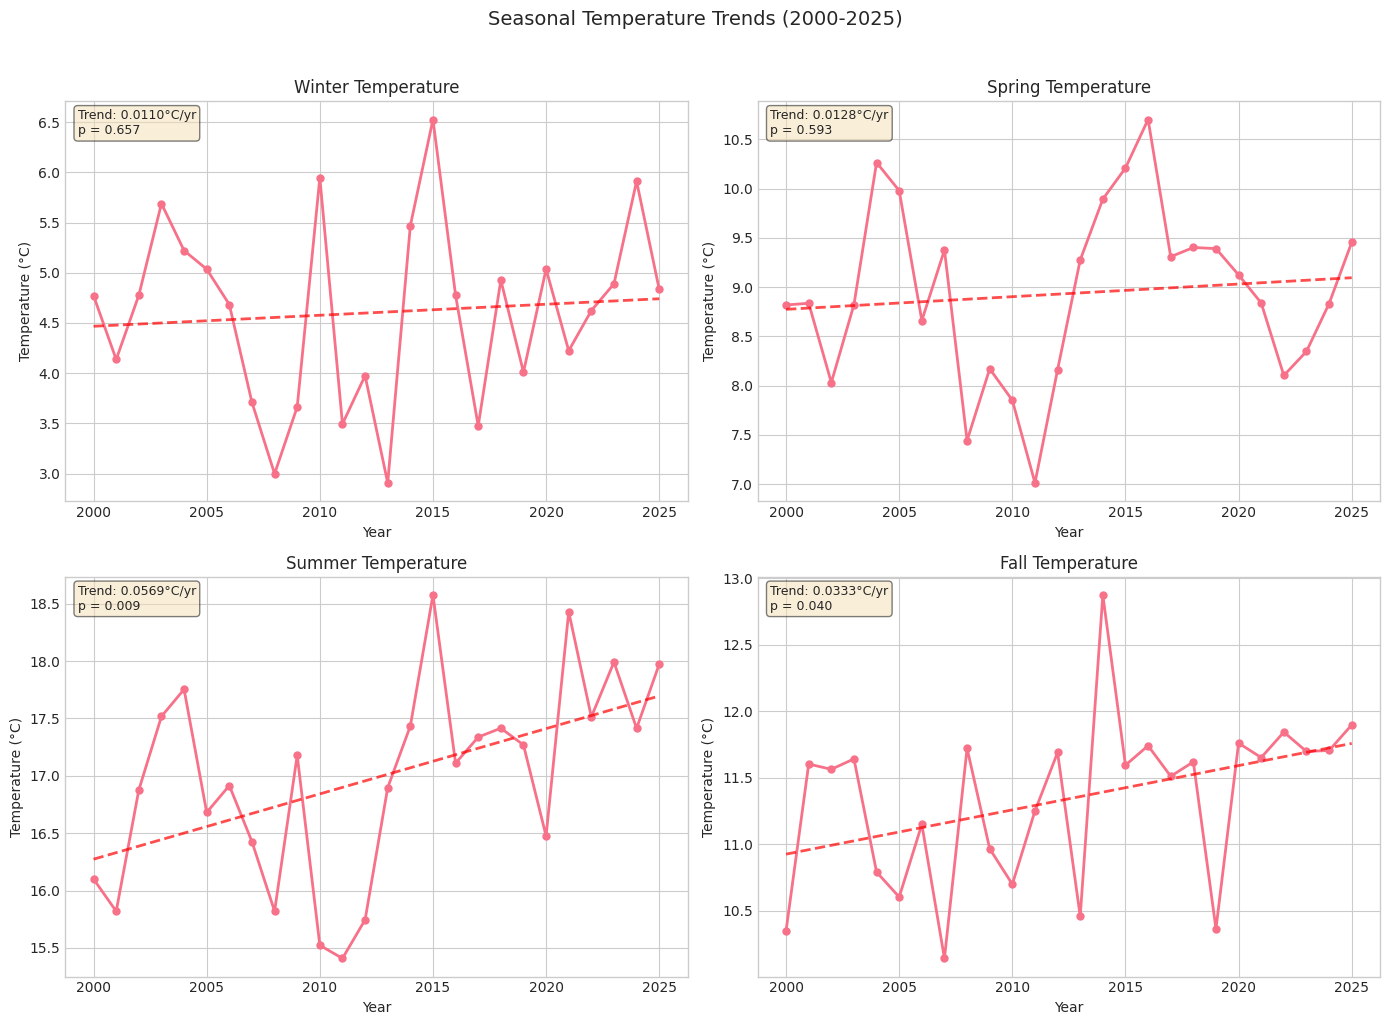


Seasonal Temperature Trend Summary:
------------------------------------------------------------
  Winter  : +0.0110°C/year (p=0.657) 
  Spring  : +0.0128°C/year (p=0.593) 
  Summer  : +0.0569°C/year (p=0.009) *
  Fall    : +0.0333°C/year (p=0.040) *


In [6]:
# Plot seasonal temperatures
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
seasons = ['winter', 'spring', 'summer', 'fall']

for idx, season in enumerate(seasons):
    ax = axes[idx // 2, idx % 2]
    
    season_data = seasonal_temp[seasonal_temp['season'] == season]
    
    ax.plot(season_data['year'], season_data['temp_mean_c'], 'o-', 
            linewidth=2, markersize=5)
    
    # Add trend line
    slope, intercept, r_value, p_value, std_err = stats.linregress(
        season_data['year'], season_data['temp_mean_c']
    )
    ax.plot(season_data['year'], intercept + slope * season_data['year'], 
            'r--', linewidth=2, alpha=0.7)
    
    ax.set_title(f'{season.capitalize()} Temperature', fontsize=12)
    ax.set_xlabel('Year')
    ax.set_ylabel('Temperature (°C)')
    ax.text(0.02, 0.98, f'Trend: {slope:.4f}°C/yr\np = {p_value:.3f}', 
            transform=ax.transAxes, fontsize=9, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Seasonal Temperature Trends (2000-2025)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Summary of seasonal trends
print("\nSeasonal Temperature Trend Summary:")
print("-" * 60)
for season in seasons:
    season_data = seasonal_temp[seasonal_temp['season'] == season]
    slope, _, r_value, p_value, _ = stats.linregress(
        season_data['year'], season_data['temp_mean_c']
    )
    sig = "*" if p_value < 0.05 else ""
    print(f"  {season.capitalize():8s}: {slope:+.4f}°C/year (p={p_value:.3f}) {sig}")

## 4. Precipitation Trends

Analyze annual and seasonal precipitation patterns.

In [7]:
# Annual precipitation totals (sum per field-year, then average across fields)
annual_per_field = monthly.groupby(['field_id', 'year'])['precip_total_mm'].sum().reset_index()
annual_precip = annual_per_field.groupby('year')['precip_total_mm'].mean().reset_index()

print("Annual Precipitation:")
annual_precip

Annual Precipitation:


,year,precip_total_mm
0,2000,1189.8804
1,2001,1239.6612
2,2002,1290.9846
3,2003,1517.2132
4,2004,1213.8656
5,2005,1304.9418
6,2006,1617.8562
7,2007,1365.7936
8,2008,1317.5502
9,2009,1226.1148


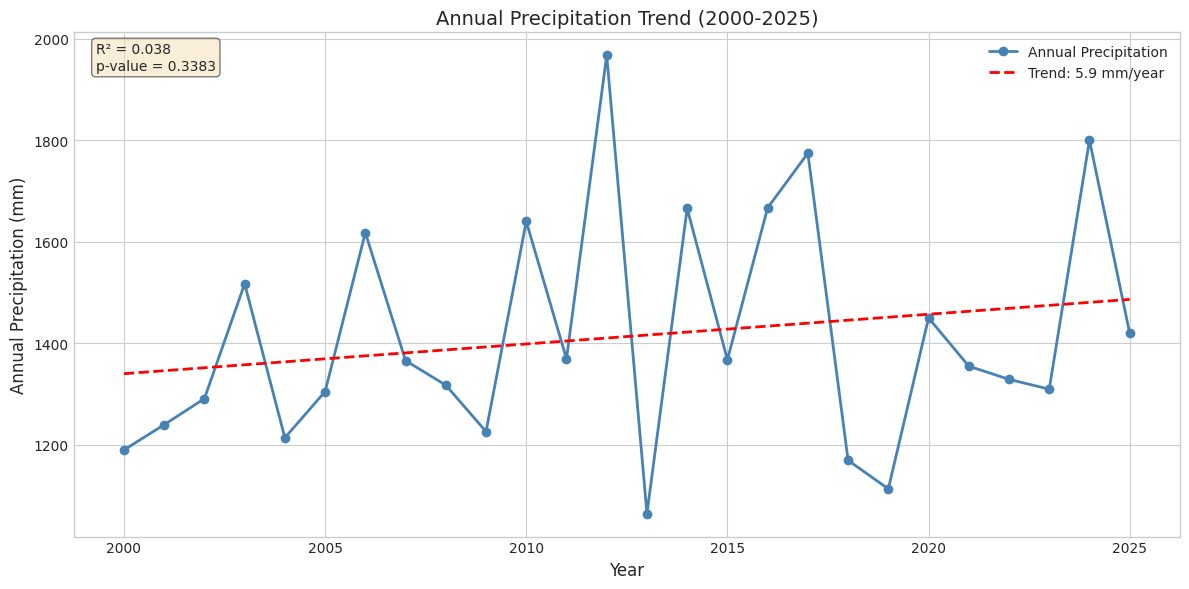


Precipitation Trend Analysis:
  Rate of change: 5.85 mm per year
  Total change over 26 years: 152.2 mm
  Statistical significance: p = 0.3383 (not significant)


In [8]:
# Plot annual precipitation
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(annual_precip['year'], annual_precip['precip_total_mm'], 'o-', 
        color='steelblue', linewidth=2, markersize=6, label='Annual Precipitation')

# Add trend line
slope, intercept, r_value, p_value, std_err = stats.linregress(
    annual_precip['year'], annual_precip['precip_total_mm']
)
ax.plot(annual_precip['year'], intercept + slope * annual_precip['year'], 
        'r--', linewidth=2, label=f'Trend: {slope:.1f} mm/year')

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Annual Precipitation (mm)', fontsize=12)
ax.set_title('Annual Precipitation Trend (2000-2025)', fontsize=14)
ax.legend()

ax.text(0.02, 0.98, f'R² = {r_value**2:.3f}\np-value = {p_value:.4f}', 
        transform=ax.transAxes, fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

print(f"\nPrecipitation Trend Analysis:")
print(f"  Rate of change: {slope:.2f} mm per year")
print(f"  Total change over 26 years: {slope * 26:.1f} mm")
print(f"  Statistical significance: p = {p_value:.4f} ({'significant' if p_value < 0.05 else 'not significant'})")

Precipitation patterns directly impact irrigation needs and crop health. The Willamette Valley's Mediterranean climate relies heavily on winter rainfall to refill soil moisture reserves. This section examines both annual totals and winter rainfall trends critical for water resource planning.



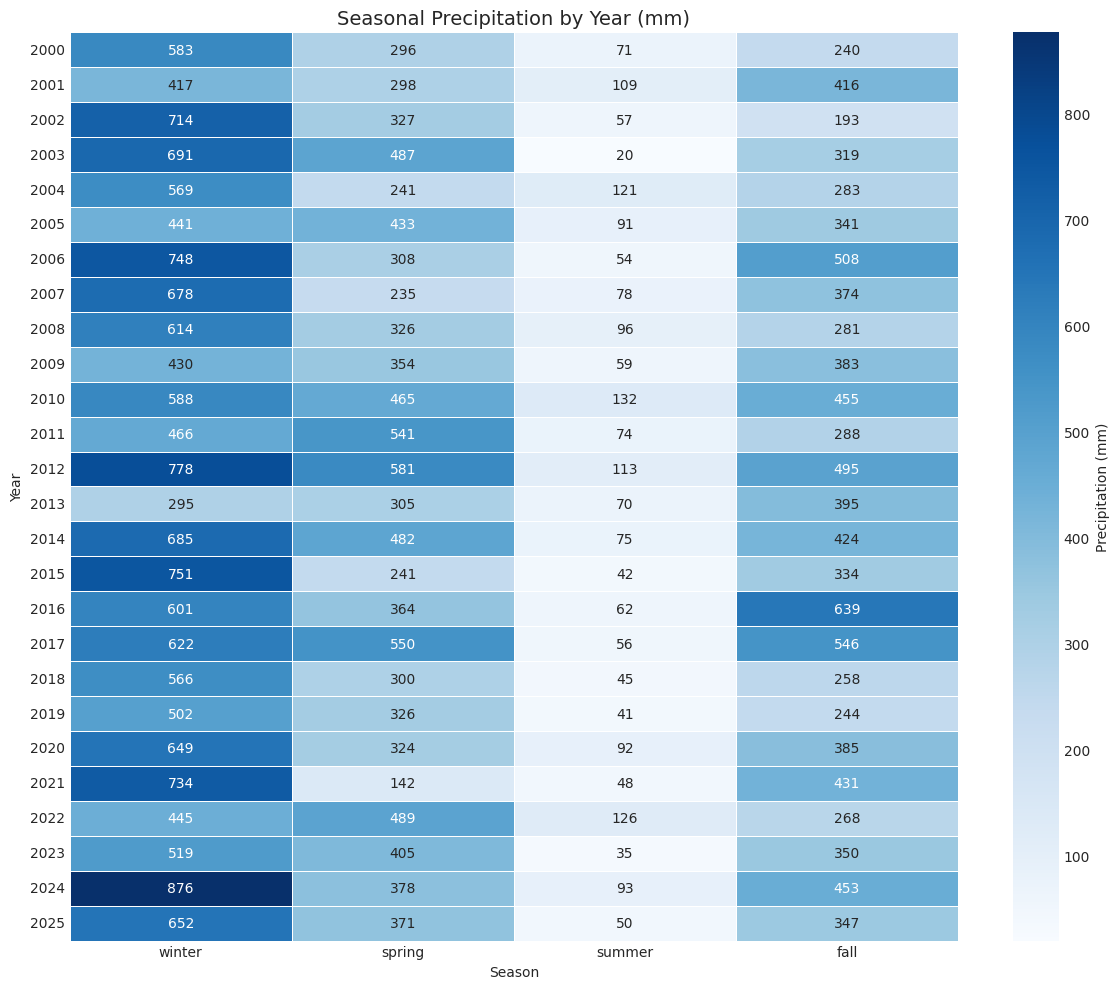

In [9]:
# Seasonal precipitation analysis (sum per field-year-season, then average across fields)
seasonal_per_field = monthly.groupby(['field_id', 'year', 'season'])['precip_total_mm'].sum().reset_index()
seasonal_precip = seasonal_per_field.groupby(['year', 'season'])['precip_total_mm'].mean().reset_index()

# Pivot for heatmap
seasonal_precip_pivot = seasonal_precip.pivot(index='year', columns='season', values='precip_total_mm')
seasonal_precip_pivot = seasonal_precip_pivot[['winter', 'spring', 'summer', 'fall']]

# Plot heatmap
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(seasonal_precip_pivot, annot=True, fmt='.0f', cmap='Blues', 
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Precipitation (mm)'})
ax.set_title('Seasonal Precipitation by Year (mm)', fontsize=14)
ax.set_xlabel('Season')
ax.set_ylabel('Year')

plt.tight_layout()
plt.show()

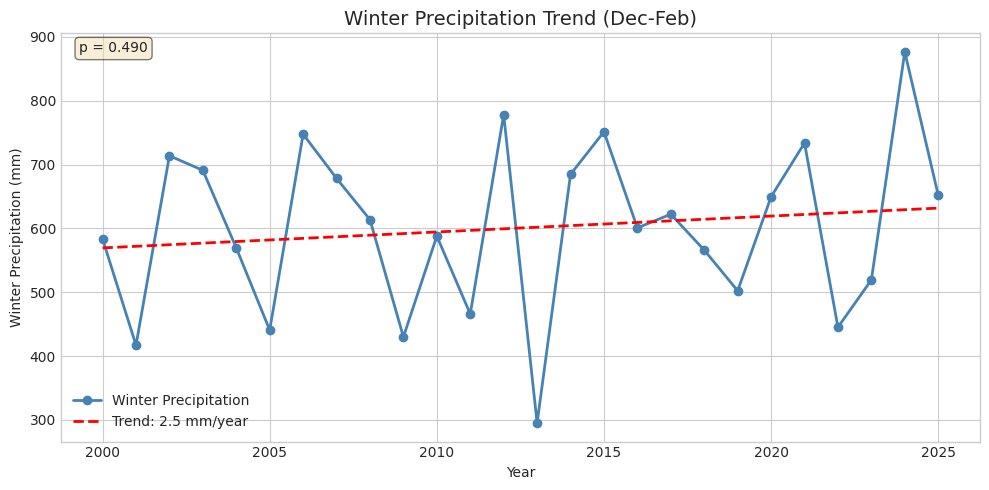


Winter Precipitation Trend:
  Change: 2.49 mm/year
  Over 26 years: 64.8 mm
  Statistical significance: p = 0.4898 (not significant)


In [10]:
# Winter precipitation trend (key question: is winter rain decreasing?)
winter_precip = seasonal_precip[seasonal_precip['season'] == 'winter']

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(winter_precip['year'], winter_precip['precip_total_mm'], 'o-', 
        color='steelblue', linewidth=2, markersize=6, label='Winter Precipitation')

# Trend line
slope, intercept, r_value, p_value, std_err = stats.linregress(
    winter_precip['year'], winter_precip['precip_total_mm']
)
ax.plot(winter_precip['year'], intercept + slope * winter_precip['year'], 
        'r--', linewidth=2, label=f'Trend: {slope:.1f} mm/year')

ax.set_xlabel('Year')
ax.set_ylabel('Winter Precipitation (mm)')
ax.set_title('Winter Precipitation Trend (Dec-Feb)', fontsize=14)
ax.legend()

ax.text(0.02, 0.98, f'p = {p_value:.3f}', 
        transform=ax.transAxes, fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

print(f"\nWinter Precipitation Trend:")
print(f"  Change: {slope:.2f} mm/year")
print(f"  Over 26 years: {slope * 26:.1f} mm")
print(f"  Statistical significance: p = {p_value:.4f} ({'significant' if p_value < 0.05 else 'not significant'})")

## 5. Growing Degree Days (GDD) Analysis

Analyze how GDD accumulation is changing over time, which affects crop development.

In [11]:
# Annual GDD totals (sum per field-year, then average across fields)
annual_per_field = monthly.groupby(['field_id', 'year'])['gdd_total'].sum().reset_index()
annual_gdd = annual_per_field.groupby('year')['gdd_total'].mean().reset_index()

print("Annual GDD (Base 10°C):")
annual_gdd

Annual GDD (Base 10°C):


,year,gdd_total
0,2000,910.4843
1,2001,991.1384
2,2002,1034.5013
3,2003,1179.1176
4,2004,1135.7012
5,2005,1035.3792
6,2006,1078.4911
7,2007,943.2811
8,2008,950.4575
9,2009,1063.3907


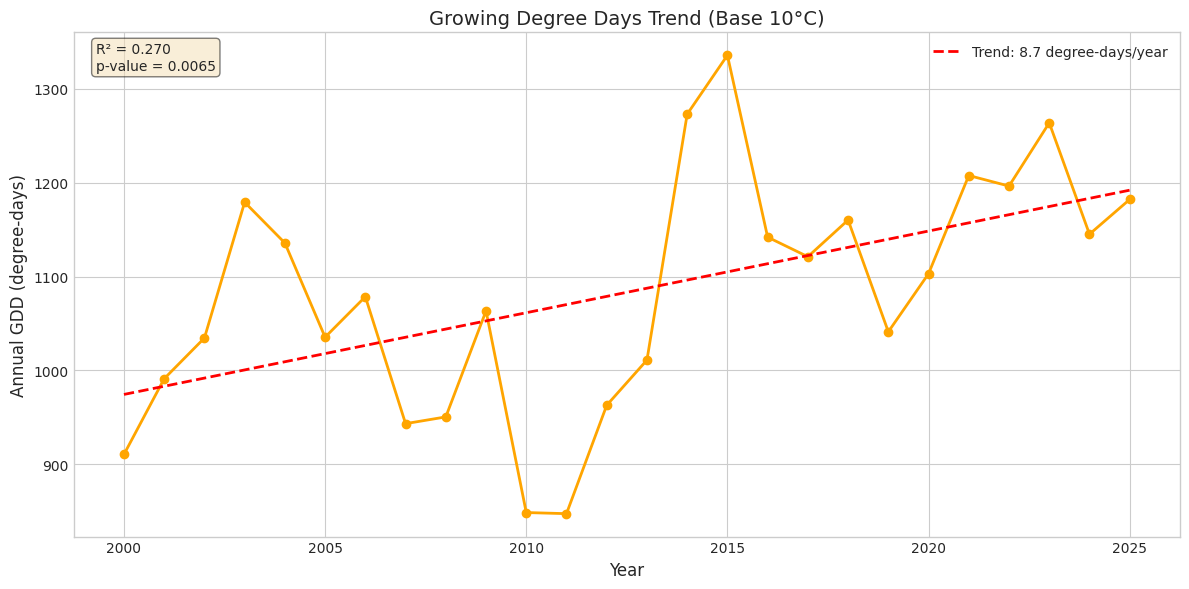


GDD Trend Analysis:
  Rate of change: 8.70 degree-days per year
  Total change over 26 years: 226.3 degree-days
  Statistical significance: p = 0.0065 (significant)


In [12]:
# Plot GDD trend
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(annual_gdd['year'], annual_gdd['gdd_total'], 'o-', 
        color='orange', linewidth=2, markersize=6)

# Trend line
slope, intercept, r_value, p_value, std_err = stats.linregress(
    annual_gdd['year'], annual_gdd['gdd_total']
)
ax.plot(annual_gdd['year'], intercept + slope * annual_gdd['year'], 
        'r--', linewidth=2, label=f'Trend: {slope:.1f} degree-days/year')

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Annual GDD (degree-days)', fontsize=12)
ax.set_title('Growing Degree Days Trend (Base 10°C)', fontsize=14)
ax.legend()

ax.text(0.02, 0.98, f'R² = {r_value**2:.3f}\np-value = {p_value:.4f}', 
        transform=ax.transAxes, fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

print(f"\nGDD Trend Analysis:")
print(f"  Rate of change: {slope:.2f} degree-days per year")
print(f"  Total change over 26 years: {slope * 26:.1f} degree-days")
print(f"  Statistical significance: p = {p_value:.4f} ({'significant' if p_value < 0.05 else 'not significant'})")

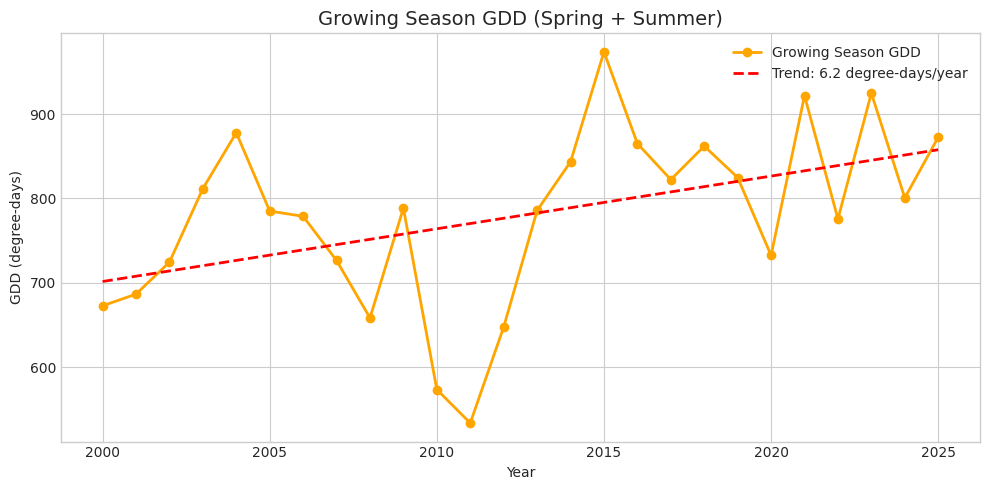

In [13]:
# Seasonal GDD (sum per field-year-season, then average across fields)
seasonal_per_field = monthly.groupby(['field_id', 'year', 'season'])['gdd_total'].sum().reset_index()
seasonal_gdd = seasonal_per_field.groupby(['year', 'season'])['gdd_total'].mean().reset_index()

# Focus on growing season (spring + summer)
growing_season = seasonal_gdd[seasonal_gdd['season'].isin(['spring', 'summer'])]
growing_by_year = growing_season.groupby('year')['gdd_total'].sum().reset_index()

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(growing_by_year['year'], growing_by_year['gdd_total'], 'o-', 
        color='orange', linewidth=2, markersize=6, label='Growing Season GDD')

# Trend line
slope, intercept, r_value, p_value, std_err = stats.linregress(
    growing_by_year['year'], growing_by_year['gdd_total']
)
ax.plot(growing_by_year['year'], intercept + slope * growing_by_year['year'], 
        'r--', linewidth=2, label=f'Trend: {slope:.1f} degree-days/year')

ax.set_xlabel('Year')
ax.set_ylabel('GDD (degree-days)')
ax.set_title('Growing Season GDD (Spring + Summer)', fontsize=14)
ax.legend()

plt.tight_layout()
plt.show()

Growing Degree Days measure heat accumulation critical for crop development, phenology timing, and yield predictions. Changes in GDD affect crop maturity dates, harvest timing, and variety selection for crops like sweet corn, beans, and other warm-season vegetables grown in the Valley.



## 6. Summary Statistics

In [14]:
# Compile summary statistics
summary_data = []

# Temperature trend
slope_t, _, r_t, p_t, _ = stats.linregress(annual_temp['year'], annual_temp['temp_mean_c'])
summary_data.append({
    'Metric': 'Annual Temperature',
    'Trend (per year)': f'{slope_t:+.4f}°C',
    '26-year change': f'{slope_t*26:+.2f}°C',
    'R²': f'{r_t**2:.3f}',
    'p-value': f'{p_t:.4f}',
    'Significant': 'Yes' if p_t < 0.05 else 'No'
})

# Precipitation trend
slope_p, _, r_p, p_p, _ = stats.linregress(annual_precip['year'], annual_precip['precip_total_mm'])
summary_data.append({
    'Metric': 'Annual Precipitation',
    'Trend (per year)': f'{slope_p:+.1f} mm',
    '26-year change': f'{slope_p*26:+.1f} mm',
    'R²': f'{r_p**2:.3f}',
    'p-value': f'{p_p:.4f}',
    'Significant': 'Yes' if p_p < 0.05 else 'No'
})

# GDD trend
slope_g, _, r_g, p_g, _ = stats.linregress(annual_gdd['year'], annual_gdd['gdd_total'])
summary_data.append({
    'Metric': 'Annual GDD',
    'Trend (per year)': f'{slope_g:+.1f} days',
    '26-year change': f'{slope_g*26:+.1f} days',
    'R²': f'{r_g**2:.3f}',
    'p-value': f'{p_g:.4f}',
    'Significant': 'Yes' if p_g < 0.05 else 'No'
})

# Winter precipitation trend
slope_w, _, r_w, p_w, _ = stats.linregress(winter_precip['year'], winter_precip['precip_total_mm'])
summary_data.append({
    'Metric': 'Winter Precipitation',
    'Trend (per year)': f'{slope_w:+.1f} mm',
    '26-year change': f'{slope_w*26:+.1f} mm',
    'R²': f'{r_w**2:.3f}',
    'p-value': f'{p_w:.4f}',
    'Significant': 'Yes' if p_w < 0.05 else 'No'
})

summary_df = pd.DataFrame(summary_data)
print("=" * 80)
print("CLIMATE TREND SUMMARY (2000-2025)")
print("=" * 80)
print(summary_df.to_string(index=False))
print("=" * 80)

CLIMATE TREND SUMMARY (2000-2025)
              Metric Trend (per year) 26-year change    R² p-value Significant
  Annual Temperature        +0.0285°C        +0.74°C 0.141  0.0591          No
Annual Precipitation          +5.9 mm      +152.2 mm 0.038  0.3383          No
          Annual GDD        +8.7 days    +226.3 days 0.270  0.0065         Yes
Winter Precipitation          +2.5 mm       +64.8 mm 0.020  0.4898          No


In [15]:
# Key Findings
print("\n" + "=" * 80)
print("KEY FINDINGS")
print("=" * 80)

# Temperature
if slope_t > 0 and p_t < 0.05:
    print(f"✓ temperatures are INCREASING significantly ({slope_t*26:.1f}°C over 26 years)")
elif slope_t > 0:
    print(f"• Temperatures appear to be increasing but not significantly")
else:
    print(f"• Temperatures are stable or decreasing")

# Summer temperature
summer_data = seasonal_temp[seasonal_temp['season'] == 'summer']
slope_s, _, _, p_s, _ = stats.linregress(summer_data['year'], summer_data['temp_mean_c'])
if slope_s > 0 and p_s < 0.05:
    print(f"✓ SUMMERS ARE GETTING HOTTER ({slope_s*26:.1f}°C warmer over 26 years)")
elif slope_s > 0:
    print(f"• Summers may be getting hotter but not significantly")

# Winter precipitation
if slope_w < 0 and p_w < 0.05:
    print(f"✓ WINTER RAIN IS DECREASING significantly ({abs(slope_w*26):.0f}mm less over 26 years)")
elif slope_w < 0:
    print(f"• Winter rain appears to be decreasing but not significantly")

# GDD
if slope_g > 0 and p_g < 0.05:
    print(f"✓ GDD IS INCREASING significantly ({slope_g*26:.0f} more degree-days over 26 years)")
elif slope_g > 0:
    print(f"• GDD appears to be increasing but not significantly")

print("=" * 80)


KEY FINDINGS
• Temperatures appear to be increasing but not significantly
✓ SUMMERS ARE GETTING HOTTER (1.5°C warmer over 26 years)
✓ GDD IS INCREASING significantly (226 more degree-days over 26 years)


This section synthesizes the key findings from our trend analyses to answer the core research questions posed at the outset. Understanding these climate trends helps growers adapt through changes in crop selection, planting dates, and irrigation management.



## 7. References

### Data Sources

| Source | Description | URL |
|--------|-------------|-----|
| **NASA POWER** | Prediction Of Worldwide Energy Resources - daily weather data (2000-2025) | https://power.larc.nasa.gov/ |
| **Field Boundaries** | Oregon Willamette Valley agricultural fields (50 fields) | USDA NASS Crop Sequence Boundaries |

### Methodological References

- **ET0 (Reference Evapotranspiration):** FAO-56 Penman-Monteith equation (Allen, R.G., Pereira, L.S., Raes, D., Smith, M., 1998). *Crop Evapotranspiration - Guidelines for Computing Crop Water Requirements*. FAO Irrigation and Drainage Paper 56. Rome, Italy: FAO.

- **GDD (Growing Degree Days):** GDD = max(0, min((T_max + T_min)/2, 30) - 10)
  - Base temperature: 10°C (suitable for corn/soybeans)
  - Cap temperature: 30°C
